# Environment Setup and Installation

Before running the cells below, you can set up a local virtual environment and install the required dependencies:

```bash
# 1. Create a virtual environment (run in your terminal at the project root)
python -m venv .venv

# 2. Activate the virtual environment
# On Linux/macOS:
source .venv/bin/activate
# On Windows:
.venv\Scripts\activate
```

Alternatively, run the cell below to install all project dependencies directly.

In [ ]:
# Install the required dependencies in the active Jupyter kernel
%pip install -r ../requirements.txt

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

# Import pipeline steps from modularized files
from src.load_terrain import load_terrain
from src.generate_terrain import generate_terrain
from src.build_quadtree import quadtree_regions, calculate_region_stats, draw_quadtree
from src.create_points import (
    sample_poisson_disk_points_numba,
    round_and_clamp_points,
    build_height_point_cloud,
    get_edges,
    plot_2d_delaunay,
    plot_3d_pointcloud_pyvista,
    plot_terrain_surface_pyvista,
    find_nearest_point_index,
    filter_border_edges
)
from src.create_graph import make_graph, astar, smooth_path
from src.select_points import select_points
from src.config import (
    DEFAULT_TERRAIN_PATH,
    DEFAULT_METRIC_RESOLUTION,
    GEOGRAPHIC_DEGREE_THRESHOLD,
    INITIAL_QUADTREE_MAX_DEPTH,
    INITIAL_QUADTREE_MIN_VARIANCE,
    VARIANCE_PERCENTILE_THRESHOLD,
    FINAL_QUADTREE_MAX_DEPTH,
    DEFAULT_MIN_DEPTH,
    MAIN_MAX_RADIUS,
    MAIN_MIN_RADIUS,
    MAIN_SLOPE_PENALTY_ALPHA,
    SMOOTH_PATH,
    SMOOTH_PATH_LAMBDA
)

# Programming-project: Optimal path finder in a mountainous terrain.

*Luuk van der Duim - 9/7/2026*

![title](front_page.png)

#### In short:
In this notebook I explain the process of my programming project. This project combines the usage of geographical data, finding an efficient algorithm with mathematical techniques and finetuning the algorithm with parameters to create a fun path-finding tool that works well for complex terrain.

#### Why?

I started this project because I was curious about how I could load in geographical data in Python and analyse it, since I am interested in Geography and wanted to use my programming skills I gained from my first year Artificial Intelligence with it. I knew how to find the optimal path in a graph of nodes with A* search and had the idea of applying it to the geographical data in order to find the optimal path through a mountainous terrain. This seemed like a fun project for me to learn the basics of using geo-data. And along the way I learned about some new datastructures, graph-theory and practical skills in setting up a coding project.

#### Technical details:
- **Language:** Python
- **Libraries used:** numpy, scipy, rasterio, networkit, matplotlib, pyvista
- **Algorithms:** Quadtree decomposition, Poisson Disk Sampling, Delaunay Triangulation, A* search

For transparency purposes, I used the help of generative AI tools (such as Copilot) for:
- Refactoring code
- Troubleshooting
  
Since this was a project for fun and to learn, I always made sure to understand any changes made :)
    























# 1. Process & Examples

In this section a short overview is given in the techniques used and the overall process, followed by a written out pseudocode which encapsulates the logic of the code.

This programming project started with me wanting to learn how to analyse
geographical data. Therefore I started with downloading QGIS and attempted to get a heightmap from an area in Norway (since I am going on a trip to Norway it would be nice to get the optimal path for a hike). After a bit of trial and error I managed to select an area and download it as a .tif file.

## 1.1 Quadtree decomposition 
In order to get A* to run I needed a graph with nodes and edges, but I realised quickly that for a large area (for example a height map with 1000x1000 entries or larger) it would mean I needed to run it on a graph with over millions of nodes, which is possible, but possibly a waste of computational time.

So how can this be reduced? I had the idea that not every part of a region has the same complexity, some regions have a lot of variation in height, and therefore need more nodes to describe its topology. We do not want the algorithm to take large steps between cliffs for example. On the contrary a flat landscape / small hill does not need nearly the same amount of nodes to describe it. To implement this idea we need a way to distribute nodes among the terrain such that area's with a higher variation have a denser amount of nodes, and it turns out a nice way to locate and bound complex regions is by building a *Quadtree*.

### 1.1.1 How to build a quadtree decomposition

The quadtree decomposition is build using the following logic:

1. Divide the height map into 4 quadrants
2. For each quadrant, calculate the variation in height.
3. If the variation is higher than a given minimum variation, divide the quadrant again.
4. Continue this process until no division is possible, or if the maximum depth is reached.

Below is a simple visualisation of a quadtree:

![Simple visualisation of a quadtree structure:](quadtreeimage.webp)

### 1.1.2 Choosing the variation treshold

It is assumed in the explanation above that we have a given minimum variation, but how do be obtain a logical threshold? We need a metric which encapsulates a low or high variation, based on the overall terrain. We choose the minimum variation as follows:

1. Divide the height map into the maximum amount of regions, based on the given depth ($4^d$ regions).
2. For each region, calculate the variation in height.
3. Calculate the x-th percentile of variation across all regions, and set as minimum variation.

This approach makes sure that the quadtree decomposition tries to reach the maximum depth as much as possible, and only stops when terrain is really flat.

### 1.1.3 Choosing the percentile and depth
The choice of x is important for the overall performance of the algorithm. If x is low (<50) the quadtree will return less regions and therefore lose accuracy and if x is high (>90) it will return more regions resulting in a more accurate result. 

The choice of depth is also an important factor for accuracy, if the depth is high more regions can be returned and of course if it is low less regions will be returned. Inceasing the depth by one means the maximum number of regions is multiplied by 4, therefore it grows exponentially. Mathematically the depth is unbounded, but choosing a depth > 10 is not recommended since the maximum number of regions by then already exceeds the million (which we wanted to optimize in the first place).

**Important**: Both the percentile and the depth are parameters and it is my intention to analyse how to choose them in a optimal way depending on the problem later, for now I chose what works best after experimenting. Refer to this for any future parameter.

### 1.1.4 Quadtree Pseudocode:

def quadtree_regions(`terrain`, `current_depth`=0, `max_depth`, `min_variance`):

1. **If** `current_depth` > `max_depth`, add terrain as a leaf node.
2. Divide terrain into 4 quadrants.
3. **For** each quadrant:
    * Calculate the height variation $\sigma^2$.
    * **If** $\sigma^2 > $ `min_variance`, recursively call `quadtree_regions` on the quadrant.
    * **Else**, it is a leaf node (it has no children in the tree).

`min_variance` is chosen as follows:
 - Divide terrain in $4^d$ regions, with $d$ = `max_depth`. This is done by calling `quadtree_regions(terrain, max_depth=d, min_variance=0)`
 - Calculate height-varions for all regions.
 - Calculate the 95th percentile (arbitrarily chosen for now) and set as `min_variance`.

### 1.1.5 Quadtree example
Run the code cell below to see a visualisation of a quadtree decomposition applied to a artificially generated terrain (for example purposes):

Terrain successfully loaded. Matrix shape: (541, 1322)
Decomposing terrain using Quadtree...
Quadtree generated 5341 leaf regions.


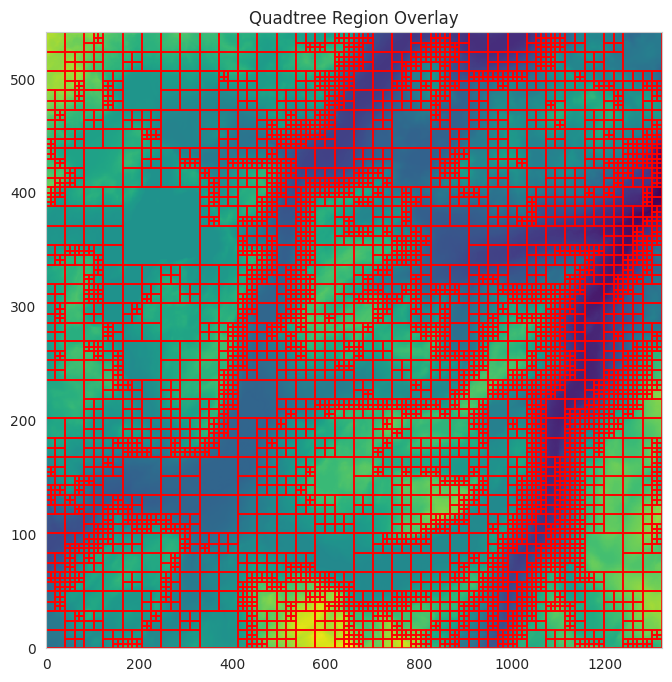

In [33]:
DEFAULT_QUADTREE_MAX_DEPTH = 7
DEFAULT_QUADTREE_MIN_VARIANCE = 5.0
INITIAL_QUADTREE_MAX_DEPTH = 7
INITIAL_QUADTREE_MIN_VARIANCE = 0.0
FINAL_QUADTREE_MAX_DEPTH = 7
VARIANCE_PERCENTILE_THRESHOLD = 95
MIN_SUBREGION_SIZE = 1

file_path="../terrain/norway_fjord.tif"

terrain = load_terrain(file_path)

print("Decomposing terrain using Quadtree...")
# Calculate initial regions for variance statistics
initial_regions = quadtree_regions(terrain, max_depth=INITIAL_QUADTREE_MAX_DEPTH, min_variance=INITIAL_QUADTREE_MIN_VARIANCE)
stats = calculate_region_stats(terrain, initial_regions)
stats_variances = [s['var'] for s in stats]

# Filter regions based on the 95th percentile of variance
min_variance = np.percentile(stats_variances, VARIANCE_PERCENTILE_THRESHOLD) if len(stats_variances) > 0 else 0
regions = quadtree_regions(terrain, max_depth=FINAL_QUADTREE_MAX_DEPTH, min_variance=min_variance)
print(f"Quadtree generated {len(regions)} leaf regions.")

# Plot quadtree

draw_quadtree(terrain, regions, max_depth=INITIAL_QUADTREE_MAX_DEPTH, show=True)

## 1.2 Poisson Disk Sampling

With Quadtree decomposition we have now created regions with a corresponding depth, the task now is to distribute points over each region. We could use random sampling to generate points, but that could create problems with points clustering or being in illogical places by pure chance. Instead we use *Poisson Disk Sampling*, which generates random points with the constraint that no two points are closer than a specified radius *r*.

#### 1.2.1 Choosing the radius:

Because of quadtree decomposition, complex regions of the terrain are described by a many small squares. For implementing Poisson Disk this means that the radius $r$ has to be smaller to allow more points to fit into these small squares. This can be achieved by choosing a upper and lower bound or $r$ for a maximum and minimum depth, and for all depths in between linearly interpolating the radius so that $r$ scales up linearly to the maximum radius for the corresponding maximum depth. Writing this in formula:

$$
r_d = r_{max} - \frac{d - d_{min}}{d_{max}- d_{min}} \cdot (r_{max}- r_{min})
$$

Choosing `MIN_RADIUS`, `MAX_RADIUS` is for now done by shortly experimenting what works best. This can be analysed later.

#### 1.2.2 Poisson Disk Sampling Pseudocode

def sample_poisson_disk_points(`regions`, `min_depth`, `max_depth`, `max_radius`, `min_radius`):
1. **For** each leaf region `reg` in `regions`:
    * Extract bounds `x`, `y`, width `w`, height `h`, and the region's `depth`.
    * Calculate the dynamic sampling radius $r_d$ for the region's `depth`.
    * Generate a unique, reproducible `seed` based on the region's coordinates `x` and `y`.
    * Initialize the Poisson Disk Sampling engine with the radius $r_d$, bounds $[x, y]$ to $[x + w, y + h]$, and the generated `seed`.
    * Generate sample points using the `scipy.stats.qmc` package.
    * Append all sampled points to the list `points`.
2. **Return** `points`

#### 1.2.3 Poisson Disk Sampling example (creating the pointcloud)
Run the code cells below to see the result of applying poisson disk sampling to every region, and plotting them against their corresponding height.

In [34]:
height, width = terrain.shape

dx, dy = DEFAULT_METRIC_RESOLUTION, DEFAULT_METRIC_RESOLUTION
try:
    import rasterio
    with rasterio.open(file_path) as src:
        res_x, res_y = src.res
        # If the resolution is extremely small (< 0.1), the coordinates are in degrees rather than meters
        R = 6371000
        if res_x < GEOGRAPHIC_DEGREE_THRESHOLD:
            # Find the borders of the tif file (left/right are in longitude, bottom/top are in latitude)
            left, bottom, right, top = src.bounds
            # Use the center latitude for a more accurate conversion from degrees to meters
            center_lat = (bottom + top) / 2.0
            center_lat_rad = np.radians(center_lat)

            # Use formula for converting degrees to meters at a given latitude
            dx = res_x * (np.cos(center_lat_rad) * np.pi * R) / 180
            dy = res_y *(np.pi * R) / 180
            print("\n" + "="*80)
            print("The loaded GeoTIFF uses geographic degrees (e.g. EPSG:4326) instead of meters.")
            print(f"The code will estimate the metric pixel size at this latitude as:")
            print(f"          dx = {dx:.2f}m, dy = {dy:.2f}m per pixel.")
            print("="*80 + "\n")
        else:
            dx, dy = res_x, res_y
            print(f"Loaded spatial resolution from TIFF: dx={dx:.3f}m, dy={dy:.3f}m per pixel")
except Exception as e:
    print(f"Using default spatial resolution: dx=1.0, dy=1.0 (No TIFF resolution found: {e})")


print("Sampling points, this could take a while depending on the parameters and size of the terrain.")
raw_points = sample_poisson_disk_points_numba(
    regions,
    min_depth=DEFAULT_MIN_DEPTH,
    max_depth=FINAL_QUADTREE_MAX_DEPTH,
    max_radius=MAIN_MAX_RADIUS,
    min_radius=MAIN_MIN_RADIUS
    )
print("Points generated succesfully.")
points = round_and_clamp_points(raw_points, width, height)
height_points = build_height_point_cloud(points, terrain)
print(f"Sampled {len(height_points)} 3D points.")

plot_3d_pointcloud_pyvista(height_points, path_3d=None, dx=dx, dy=dy)


The loaded GeoTIFF uses geographic degrees (e.g. EPSG:4326) instead of meters.
The code will estimate the metric pixel size at this latitude as:
          dx = 14.99m, dy = 30.89m per pixel.

Sampling points, this could take a while depending on the parameters and size of the terrain.
Points generated succesfully.
Sampled 73376 3D points.


Widget(value='<iframe src="http://localhost:38685/index.html?ui=P_0x7214205e49b0_15&reconnect=auto" class="pyv…

## 1.3 Delaunay Triangulation

Now that we have a set of points in order to get A* to find the optimal path, we still need edges to connect the points in a logical way. There are multiple ways to achieve this, but in this project *Delaunay Triangulation* is used.

Delaunay triangulation is used to connect the sampled points into a clean network of edges. It guarantees a fully connected graph where edges never cross and nodes connect only to their immediate neighbors.

We apply this to our points generated by Poisson Disk to generate a useable graph with NetworKit.

#### 1.3.1 Delaunay Triangulation Pseudocode
def build_triangulation_edges(`points`, `width`, `height`):
1. Compute the Delaunay triangulation of `points` in 2D space.
2. **For** each triangle simplex:
    * Extract the three edges connecting the vertices.
    * Sort each edge such that the vertex index $u < v$ (undirected edges).
    * Add each unique edge $(u, v)$ to the edge set.
3. **For** each edge $(u, v)$ in the set:
    * **If** both nodes $u$ and $v$ lie on the outer boundary of the terrain map:
        * Remove the edge from the set (filters out border edges).
4. **Return** the set of filtered unique edges.

#### 1.3.2 Delaunay Triangulation Example
Run the code cell below to see the graph which will be used to find the optimal path.

Calculating Delaunay Triangulation and extracting edges...
Extracted 219576 unique edges.


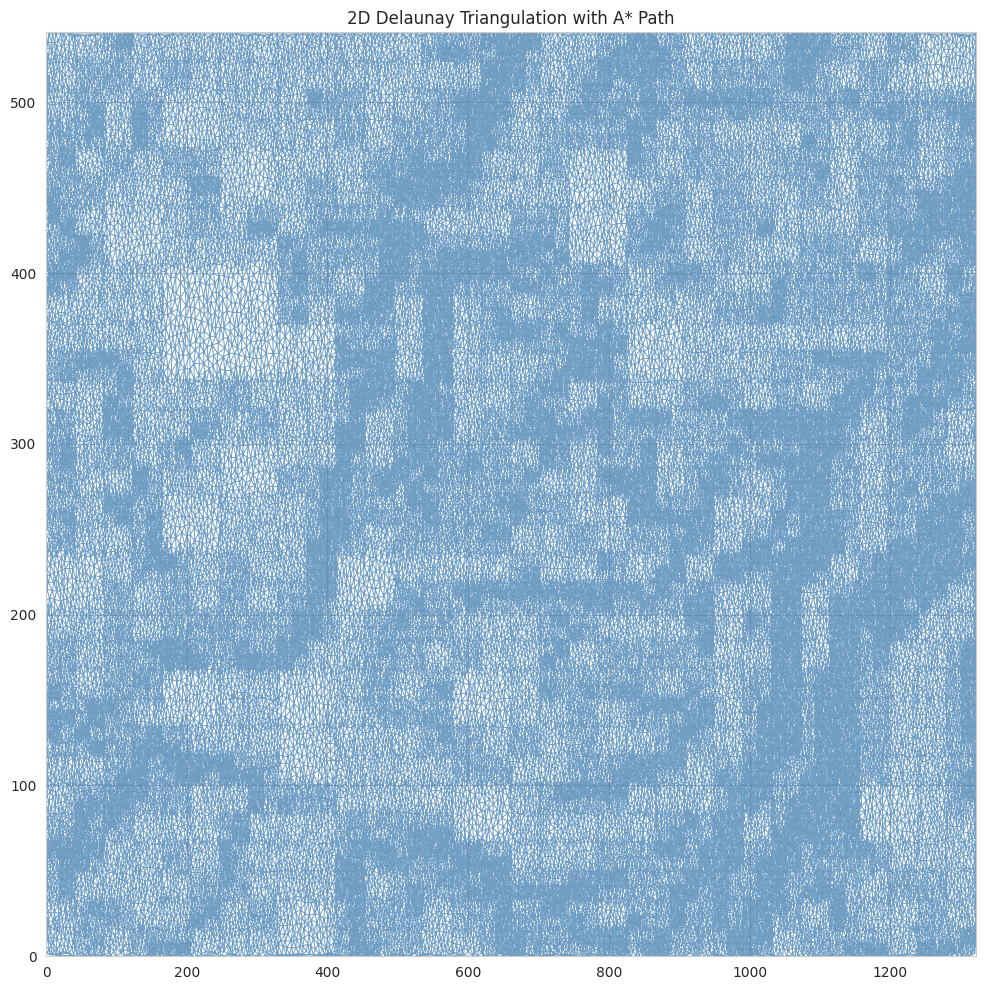

In [35]:
print("Calculating Delaunay Triangulation and extracting edges...")
triangulation = Delaunay(points)
raw_edges = get_edges(triangulation)
edges = filter_border_edges(raw_edges, points, width, height)
print(f"Extracted {len(raw_edges)} unique edges.")

plot_2d_delaunay(points, path_3d=None)

## 1.4 A* Search and smoothing
Now that we have our graph with nodes and edges, we can apply A* search to find the optimal path. But in order to do so, we still need two things:
* Weights between points
* An admissable heuristic

#### 1.4.1 Setting the weights between points

For the weights between points the following formula is used:

$$
w(\vec{a},\: \vec{b}) = ||(\vec{b}-\vec{a})|| \cdot (1 + \alpha \cdot (h(\vec{b}) - h(\vec{a}))^2)
$$

$$\text{With } \vec{a},\vec{b} \text{ two nodes with corresponding heights } h(\vec{a}), h(\vec{b})$$

In words:

$$
\text{weight} = \text{euclidian distance} \cdot (1 + \alpha \cdot \text{height difference}^2)
$$

$\alpha$ is a parameter which can be changed to tell the algorithm how much height difference matters.

The term $(1 + \alpha \cdot \text{height difference}^2)$ can essentially be seen as a work required factor, which makes sure A* does not prefer longer edges over multiple shorter ones.

As seen in the formula it is chosen that height difference is penalized quadratically, which makes sure that small increases in height get penalized less and large increases in height get penalized more.

#### 1.4.2 Choosing an admissable heuristic

The heuristic is a numerical value which tries to estimate the remaining cost to the goal node from a specific node. In order for a heuristic to be admissible it must be the case that the heuristic value never overestimates the cost to get to the goal, if it does A* is not guaranteed to find the optimal path.

Therefore an admissable heuristic to choose it simply the euclidian distance between the node and the goal node, since no path can be better than a direct line since all our weights are positive.

#### 1.4.3 A* Search Pseudocode
def find_shortest_path(`edges`, `height_points`, `start_coord`, `end_coord`, `alpha`):
1. Find the nearest graph node indices `source_idx` and `target_idx` to `start_coord` and `end_coord`.
2. Initialize a new weighted graph with vertices equal to the number of points.
3. **For** each edge $(u, v)$ in `edges`:
    * Calculate the euclidian distance $D$ between node $u$ and node $v$.
    * Calculate the slope $s$ between the two nodes
    * Compute the weighted cost: $w = D \cdot (1 + \alpha \cdot s^2)$.
    * Add the weighted edge $(u, v)$ with cost $w$ to the graph.
4. Compute the admissible heuristic $h(u)$ for all nodes $u$ (3D Euclidean distance from node $u$ to the target node).
5. Run the A* shortest path algorithm from `source_idx` to `target_idx` using the graph and heuristic $h(u)$.
6. Reconstruct the sequence of 3D node coordinates along the shortest path.
7. **Return** the shortest path coordinates.


## 1.5 Smoothing the optimal path with spline smoothing

The raw shortest path generated on the discrete Delaunay graph can contain sharp corners and jittery segments. To produce a more natural, realistic path for navigation, we apply a smoothing technique. Because the path is constrained to the terrain surface, we can perform smoothing in the 2D horizontal plane and then retrieve the corresponding height value from the elevation map.

#### 1.5.1 Parametizing the path

We cannot smooth the path using standard functions of the form $f(x) = y$ or $f(y) = x$, because the path can curve back on itself, wind, or loop (which would result in multiple $y$-values for a single $x$-value therefore making the path not a function). 

Instead we parameterize the coordinates using a variable $t$, representing the cumulative 2D Euclidean distance (path length) along the route from the starting node. This gives us two separate, single-valued, and monotonic functions: $x(t)$ and $y(t)$.

#### 1.5.2 Applying spline smoothing and lambda
We apply spline smoothing to the parameterized coordinate functions $x(t)$ and $y(t)$ independently using `scipy.interpolate.make_smoothing_spline`. The  parameter $\lambda$ balances the trade-off between keeping the path close to the original A* nodes and reducing the overall curvature to make it smoother. This implementation uses $\lambda=1000$

After calculating the smoothed coordinates $x(t)$ and $y(t)$, we map them back onto the original terrain matrix with corresponding $z$. This makes dure the smoothed path remains on the surface of the terrain.

#### 1.5.3 Path Smoothing Pseudocode
def smooth_path(`path_3d`, `terrain`, `lam`):
1. **For** each point in `path_3d`:
    * Calculate the cumulative 2D Euclidean distance $t$ along the path from the starting node.
    * Store $t$ as the parameter value for the current point.
2. Fit two independent cubic smoothing splines $x(t)$ and $y(t)$ using the parameter $t$ and the smoothing factor `lam` ($\lambda$).
3. Evaluate the splines at all parameter values $t$ to obtain the smoothed horizontal coordinates $x_{smooth}$ and $y_{smooth}$.
4. **For** each coordinate pair $(x_{smooth}, y_{smooth})$:
    * Look up the corresponding elevation value $z$ in the `terrain` matrix at that index.
5. Combine the smoothed horizontal coordinates and elevation values: $(x_{smooth}, y_{smooth}, z)$.
6. **Return** the smoothed 3D path coordinates.

# 1.6 Final results

#### 1.6.1 Optimal path from A to B

Execute the code below to get the optimal path from point A to B! Input your own choice of A and B in the code to get your desired path. 

Default: start_coord = (0,0), end_coord = (width,height)

In [36]:
slope_penalty_alpha = MAIN_SLOPE_PENALTY_ALPHA
print(f"Building NetworKit Graph (slope penalty alpha = {slope_penalty_alpha})...")
graph = make_graph(edges, height_points, dx=dx, dy=dy, alpha=slope_penalty_alpha)

#Select point A here!!
start_coord = (0,0)
#Select point B here!!
end_coord = (width,height)

if start_coord is not None:
    source_idx = find_nearest_point_index(points, start_coord)
    nearest_start = points[source_idx]
    start_dist = np.linalg.norm(nearest_start - np.array(start_coord))
    print(f"Nearest point to start coord {start_coord} is node {source_idx} at {tuple(nearest_start)} (dist: {start_dist:.2f} px)")
else:
    source_idx = 0

if end_coord is not None:
    target_idx = find_nearest_point_index(points, end_coord)
    nearest_end = points[target_idx]
    end_dist = np.linalg.norm(nearest_end - np.array(end_coord))
    print(f"Nearest point to end coord {end_coord} is node {target_idx} at {tuple(nearest_end)} (dist: {end_dist:.2f} px)")
else:
    target_idx = len(height_points) - 1

print(f"Finding A* shortest path from node {source_idx} to node {target_idx}...")
path_3d = astar(graph, source_idx, target_idx, height_points, dx=dx, dy=dy)

if len(path_3d) > 0:
    print(f"Path successfully found containing {len(path_3d)} nodes.")
    if SMOOTH_PATH:
        print(f"Smoothing path with lam={SMOOTH_PATH_LAMBDA}")
        path_3d = smooth_path(path_3d, terrain, lam=SMOOTH_PATH_LAMBDA)
else:
    print("Could not find a path between source and target.")

# 7. Visualization
print("Displaying visualizations...")

# Plot 3D Point Cloud and Path using PyVista (GPU, interactive)
plot_3d_pointcloud_pyvista(height_points, path_3d=path_3d, dx=dx, dy=dy)
    
# Plot complete warped 3D terrain surface and Path using PyVista (GPU, interactive)
plot_terrain_surface_pyvista(terrain, dx=dx, dy=dy, path_3d=path_3d)

print("Showing plots. Close windows to finish.")
plt.show()

Building NetworKit Graph (slope penalty alpha = 5000)...
Nearest point to start coord (0, 0) is node 57 at (1, 2) (dist: 2.24 px)
Nearest point to end coord (1322, 541) is node 73375 at (1321, 540) (dist: 1.41 px)
Finding A* shortest path from node 57 to node 73375...
Path successfully found containing 538 nodes.
Smoothing path with lam=1000
Displaying visualizations...


Widget(value='<iframe src="http://localhost:38685/index.html?ui=P_0x72142b47ad80_16&reconnect=auto" class="pyv…

Widget(value='<iframe src="http://localhost:38685/index.html?ui=P_0x7214a5f45b80_17&reconnect=auto" class="pyv…

Showing plots. Close windows to finish.


#### 1.6.2 Remarks

* Make sure to test it on your own .tif file, the more mountainous the better.
* I'll try to include some standard .tif files that can be downloaded if wanted later
* It is my intention to update this notebook later to benchmark the path and analyse the parameters